In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [11]:
file_path = "/home/ifmt-aluno/Documentos/Eduardo_3B_Info/MT_Municipios_2025(4)/MT_Municipios_2025.shp"

In [12]:
gdf=gpd.read_file(file_path)

In [13]:
gdf.head(2)

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIAO,NM_REGIAO,SIGLA_RG,CD_CONCURB,NM_CONCURB,AREA_KM2,geometry
0,5103700,Feliz Natal,510007,Sinop,5103,Sinop,51,Mato Grosso,MT,5,Centro-oeste,CO,None,None,11661.514,"POLYGON ((-55.27805 -12.66227, -55.27801 -12.6..."
1,5103809,Figueirópolis D'Oeste,510006,Mirassol D'oeste,5102,Cáceres,51,Mato Grosso,MT,5,Centro-oeste,CO,None,None,891.448,"POLYGON ((-58.59943 -15.48359, -58.59939 -15.4..."


<function matplotlib.pyplot.show(close=None, block=None)>

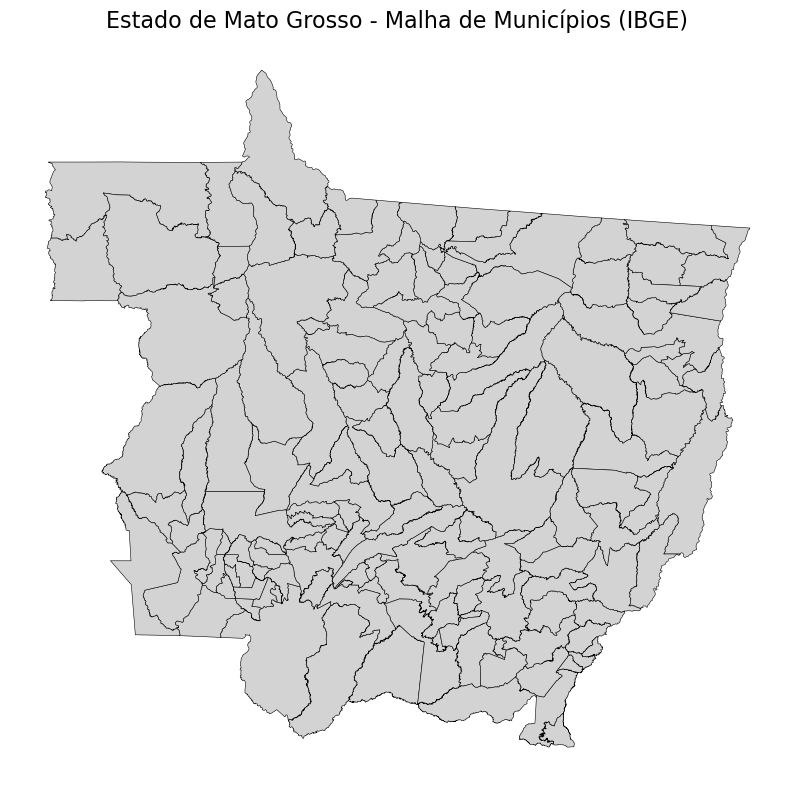

In [14]:
fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.4)

ax.set_title("Estado de Mato Grosso - Malha de Municípios (IBGE)",
            fontsize=16)
ax.axis("off")
plt.show

In [15]:
gdf_bag = gdf[gdf["NM_MUN"]=="Barra do Garças"]

In [16]:
lon=-52.25479546597344
lat=-15.89216518013151

<function matplotlib.pyplot.show(close=None, block=None)>

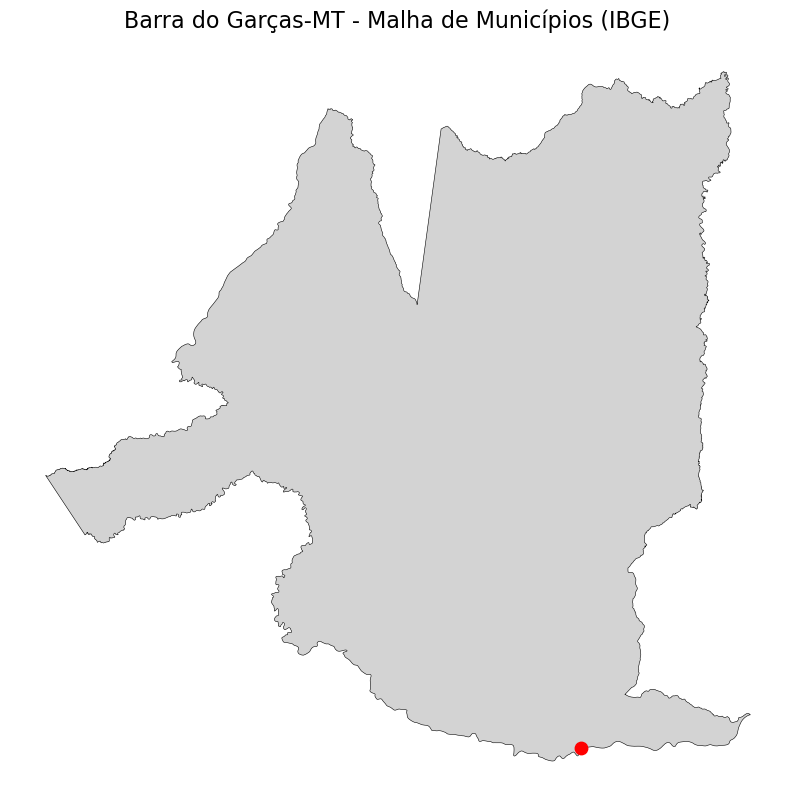

In [17]:
fig, ax = plt.subplots(figsize=(10,10))

gdf_bag.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.4)

ax.scatter(
    lon,
    lat,
    color="red",
    s=80,
    marker="o",
    label="Ponto de Interesse",
    zorder=5)

ax.set_title("Barra do Garças-MT - Malha de Municípios (IBGE)",
            fontsize=16)
ax.axis("off")
plt.show

In [18]:
import folium

In [19]:
ponto = [-15.892138291065784, -52.25481121413198]

In [20]:
mapa = folium.Map(location=ponto, zoom_start=20)

In [21]:
folium.Marker(
    location=ponto,
    popup='Ponto de Interesse',
    tooltip="Clique aqui.",
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(mapa)

In [22]:
mapa

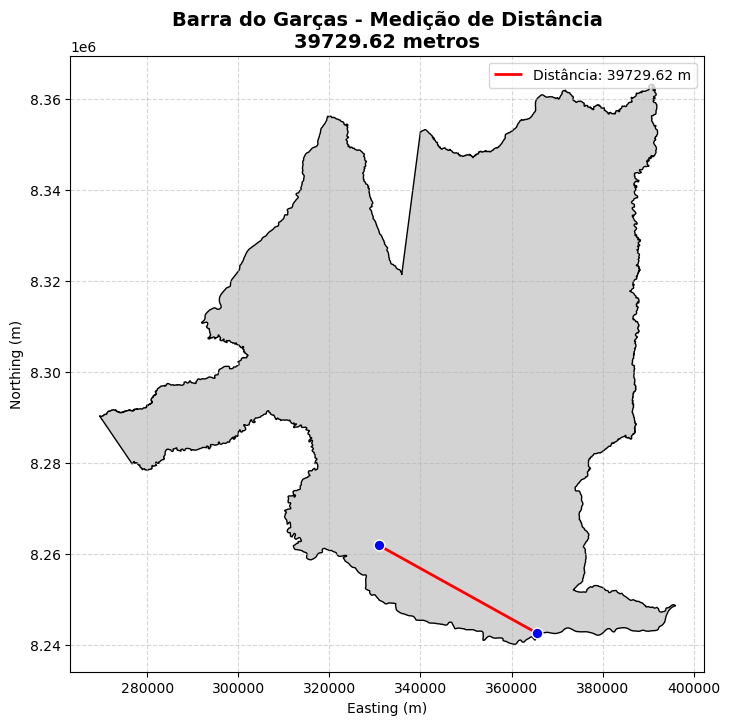

In [23]:
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import geopandas as gpd

# 1. Filtrar Barra do Garças e converter para metros (UTM 22S - EPSG:31982)
barra = gdf[gdf['NM_MUN'] == 'Barra do Garças'].to_crs(epsg=31982)

# 2. Definir os pontos (Longitude primeiro: x, dps Latitude: y)
coord1 = (-52.25481121413198, -15.892138291065784) 
coord2 = (-52.57782504821602, -15.715708441124185)

# 3. Criar GeoSeries e projetar para metros
p1 = gpd.GeoSeries([Point(coord1)], crs="EPSG:4674").to_crs(epsg=31982).iloc[0]
p2 = gpd.GeoSeries([Point(coord2)], crs="EPSG:4674").to_crs(epsg=31982).iloc[0]

# 4. Calcular a distância em METROS e criar a linha
distancia_m = p1.distance(p2)  # Removido o "/ 1000"
linha = LineString([p1, p2])

# 5. Plotagem Estática (Matplotlib)
fig, ax = plt.subplots(figsize=(10, 8))

# Desenha o polígono de Barra do Garças
barra.plot(ax=ax, color='#D3D3D3', edgecolor='black', zorder=1)

# Desenha a linha da distância (ajustado para metros no label)
gpd.GeoSeries([linha], crs=barra.crs).plot(ax=ax, color='red', linewidth=2, 
                                           label=f'Distância: {distancia_m:.2f} m', zorder=3)

# Desenha os pontos
pontos_gdf = gpd.GeoSeries([p1, p2], crs=barra.crs)
pontos_gdf.plot(ax=ax, color='blue', markersize=60, edgecolor='white', zorder=4)

# Ajustes de visualização (ajustado para metros no título)
plt.title(f'Barra do Garças - Medição de Distância\n{distancia_m:.2f} metros', fontsize=14, fontweight='bold')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

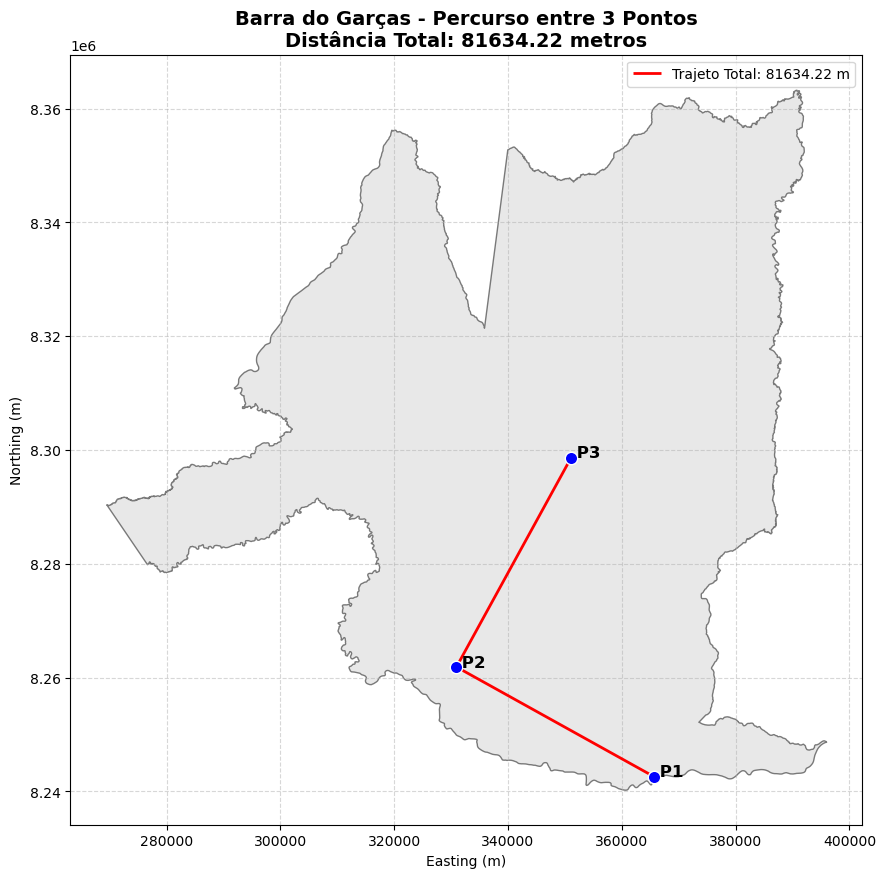

In [26]:
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import geopandas as gpd

# 1. Filtrar Barra do Garças e converter para metros
barra = gdf[gdf['NM_MUN'] == 'Barra do Garças'].to_crs(epsg=31982)

# 2. Definir os três pontos (Lembre-se: Longitude primeiro!)
coord1 = (-52.25481121413198, -15.892138291065784) 
coord2 = (-52.57782504821602, -15.715708441124185)
coord3 = (-52.387699516717696, -15.384850347817244) # Novo ponto

# 3. Criar GeoSeries e projetar para metros
p1 = gpd.GeoSeries([Point(coord1)], crs="EPSG:4674").to_crs(epsg=31982).iloc[0]
p2 = gpd.GeoSeries([Point(coord2)], crs="EPSG:4674").to_crs(epsg=31982).iloc[0]
p3 = gpd.GeoSeries([Point(coord3)], crs="EPSG:4674").to_crs(epsg=31982).iloc[0]

# 4. Calcular distâncias individuais e a total
dist1_2 = p1.distance(p2)
dist2_3 = p2.distance(p3)
dist_total = dist1_2 + dist2_3

# Criar a linha conectando os três (trajeto)
linha_trajeto = LineString([p1, p2, p3])

# 5. Plotagem
fig, ax = plt.subplots(figsize=(12, 10))

# Desenha o município
barra.plot(ax=ax, color='#D3D3D3', edgecolor='black', zorder=1, alpha=0.5)

# Desenha o trajeto conectando os 3 pontos
gpd.GeoSeries([linha_trajeto], crs=barra.crs).plot(ax=ax, color='red', linewidth=2, 
                                                  label=f'Trajeto Total: {dist_total:.2f} m', zorder=3)

# Desenha os três pontos
pontos_gdf = gpd.GeoSeries([p1, p2, p3], crs=barra.crs)
pontos_gdf.plot(ax=ax, color='blue', markersize=80, edgecolor='white', zorder=4)

# Adicionar rótulos nos pontos para identificação
for i, pt in enumerate([p1, p2, p3]):
    ax.text(pt.x, pt.y, f' P{i+1}', fontsize=12, fontweight='bold', zorder=5)

# Ajustes finais
plt.title(f'Barra do Garças - Percurso entre 3 Pontos\nDistância Total: {dist_total:.2f} metros', fontsize=14, fontweight='bold')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()